In [1]:
'''
This notebook load P-wave spectra of events recorded by D-1OB and measure Q.
There are 4 major parts:
1. Read meta data including the catalog, the configuration, the arrival picks, and the velocity mode. Get a list of events with good location for attenuation measurement.
2. Caculate channel-wise spectral ratio and save for one event. 
3. Load spectral ratio and fit the Q model to obtain Q for one event. Save the Q profile for this event.
(Repeat 2 and 3 for all available events)
4. Load all Q profiles for further analysis.

The entire procedure from spectra to source parameters is (fX00 is the number of jupyter notebook in codes/. Open the .ipynb files using jupyterlab to see the 1.2.3. numbering of the sections in each notebook): 
(1) Prepare data: 
    a. Aligned P-wave spectra (spectra/)
    b. Event catalog (catalog/event_catalog.csv) 
    c. Arrival picks (catalog/arr_picks_P)
(2) (f300) Run 1 to load meta info.
(3) (f300) Run 2. repeatedly for all events to produce travel time and incident angle files (catalog/tt_inc_P).
(4) (f400) Run 1. to load meta info.
(5) (f400) Run 2. and 3. repeatedly for many suitable events to save channel-wise spectral ratio (save/decon_for_att) and measure Q (save/Q_profiles).
(6) (f400) Run 4. to save an average 1D Q profile (models/Q_profile_P_1OB_events_fit20-200Hz.npz) corresponsding to DAS channels.
(7) (f300) Run 1 to load meta info.
(8) (f300) Run 2. and 3. repeatedly for all events to produce accumulated attenuation files (catalog/accum_att_P).
(9) (f500) Run 1 to load meta info.
(10) (f500) Run 2. and 3. repeatedly for all events to calculate source parameters (fc, m0, source radius, slip, Mw, and spectral stress drop).
(11) Implement more QC procedures (e.g., incident angle, channels, std....) as appropriate.

The codes use the CC BY-NC 4.0 license, which allows for sharing and adapting material for non-commercial purposes only.

Hilary Chang 2026.3.23
hilarych@ldeo.columbia.edu

'''

import pandas as pd
from obspy.core import UTCDateTime
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from obspy.core import Stream, Trace
import sys
from copy import copy
from scipy.interpolate import interp1d
#sys.path.append('/home/hilarych/Forge_2024/')
import utils as ut
import utm
from scipy.signal import detrend
import scipy
import time
from datetime import datetime,timedelta
from matplotlib.gridspec import GridSpec
from obspy.signal.filter import bandpass
from mpl_toolkits.axes_grid1 import make_axes_locatable
from obspy.io.segy.core import _read_segy
import matplotlib as mpl
import lmfit 
from importlib import reload
reload(ut)
plt.rcParams['figure.dpi']=50

# For Silixa iDAS
sampleFrequency=1000.
gaugeLength=10.
conversionFactor    = 116.0 * 2**-13 * sampleFrequency / gaugeLength



# =============================================================================
# The main directory that host all data and results
# opda_dir='/mnt/data0/hilarych/FORGE_2024/save/open_data_Fervo' 
opda_dir='/global/scratch/projects/pc_aieqsim/nnakata/Cape/shared_tmp_data/' 

# =============================================================================

# Read meta data

## Well location

In [2]:
#%% Well location
infile=os.path.join(opda_dir,'config','well_config.npz')
r=np.load(infile,allow_pickle=True)

ref_elev=r['ref_elev_m']
x_1OB=r['D_1OB_x_m']
y_1OB=r['D_1OB_y_m']
z_1OB=r['D_1OB_ele_m']
rec_list=np.arange(0,len(x_1OB),1) # Give each channel a number

## Velocity model

Horizontal distance between the well and the closest data point: 104.05845578271897 m


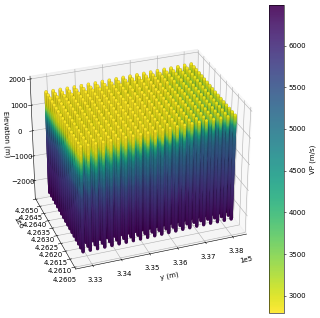

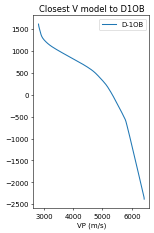

In [3]:
#%%% Velocity model
# =============================================================================
P_or_S='P'
# P_or_S='S'

# The Vp and Vs model (Forge3D_velo5D_float_01312018.sgy)seems to have an offset. I have to add these v discrepancies to match the observed arrivals.  
if P_or_S=='P':
    vp_discrepency=1200 # m/s # The Vp model seems to be 1.2 km/s slower than the obsered arrivals
elif P_or_S=='S':
    vp_discrepency=-1200 # m/s # I can match the S wave arrivals if I subtract 1.2 km/s from the Vp model
else:
    raise "P or S ???!!!"


plot_model=True
# Path of the velocity file
vel_file=os.path.join(opda_dir,'models','Forge3D_velo5D_float_01312018.sgy')

# =============================================================================


z_spacing=20 # Spacing of the data points
st = _read_segy(vel_file, unpack_trace_headers=True)
x_coords_vmodel=np.array([tr.stats.segy.trace_header['group_coordinate_x'] for tr in st])
y_coords_vmodel=np.array([tr.stats.segy.trace_header['group_coordinate_y'] for tr in st])
elevations_vmodel=np.array([tr.stats.segy.trace_header['receiver_group_elevation'] for tr in st])
# Initialize
xyzc_coords_vmodel_list=[]
for i,ele in enumerate(elevations_vmodel):
    zs=np.arange(ele,ele-len(st[i].data)*z_spacing,-z_spacing)
    cs=st[i].data+vp_discrepency
    xyzc_coords=[(x_coords_vmodel[i],y_coords_vmodel[i], zs[iz],cs[iz]) for iz in range(len(zs))]  
    xyzc_coords_vmodel_list.extend(xyzc_coords)
xyzc_coords_vmodel_list=np.array(xyzc_coords_vmodel_list)


#%%%% Get the closest velocity model to well D-1OB
def get_closest_vmodel(x,y):
    '''
    Get the closest 1D vertical v profile to easting x and northing y.
    ''' 
    dis=np.linalg.norm(np.stack([x_coords_vmodel,y_coords_vmodel],axis=-1)-\
                                 np.array([np.nanmedian(x),np.nanmedian(y)]),axis=-1)
    
    ind=np.nanargmin(dis)
    print('Horizontal distance between the well and the closest data point: %s m'%dis[ind])
    vp_profile_closest=st[ind].data+vp_discrepency
    ele_for_vp_profile_closest=np.arange(elevations_vmodel[ind],
                                             elevations_vmodel[ind]-len(st[i].data)*z_spacing,
                                             -z_spacing)
    interp_vp_func= interp1d(ele_for_vp_profile_closest,vp_profile_closest, 
                                 kind='linear', fill_value='extrapolate')
    return interp_vp_func,vp_profile_closest,ele_for_vp_profile_closest

interp_vp_func_1OB,vp_profile_closest_1OB,ele_for_vp_profile_closest_1OB=get_closest_vmodel(x_1OB,y_1OB)


if plot_model:
    # (Plot) The loaded velocity model
    # =============================================================================
    sep=1
    # =============================================================================

    fig = plt.figure(figsize=[8,8])

    x=xyzc_coords_vmodel_list[::sep,0]
    y=xyzc_coords_vmodel_list[::sep,1]
    z=xyzc_coords_vmodel_list[::sep,2]#/0.3048
    c=xyzc_coords_vmodel_list[::sep,3]
    
    ax = fig.add_subplot(111, projection='3d')
    s1=ax.scatter(x,y,z, c=c, marker='o',alpha=0.9,cmap='viridis_r',edgecolors='k',lw=0.1)
    plt.xlabel('x (m)')
    plt.xlabel('y (m)')
    ax.set_zlabel('Elevation (m)')
    # Equal aspect ratio
    world_limits = ax.get_w_lims()
    ax.set_box_aspect((world_limits[1]-world_limits[0],world_limits[3]-world_limits[2],world_limits[5]-world_limits[4]))
    
    ax.view_init(30,250)
    ax.ticklabel_format(axis='x', style='sci',scilimits=(0,0))
    cbar=plt.colorbar(s1,pad=0.01)
    cbar.ax.set_ylabel('V%s (m/s)'%P_or_S)
    plt.show()

    fig,ax=plt.subplots(figsize=[3,5])
    x=vp_profile_closest_1OB
    y=ele_for_vp_profile_closest_1OB
    plt.plot(x,y,label='D-1OB')
    plt.legend()
    plt.xlabel('V%s (m/s)'%P_or_S)

    plt.title('Closest V model to D1OB')
    plt.show()

## Channel information

In [4]:
interp_vp_func=interp_vp_func_1OB # Interpolation function to get vp at each channel
utmX_list,utmY_list,elev_list=x_1OB,y_1OB,z_1OB # Coordinates of channels
vp_profile_well=interp_vp_func(elev_list)

# Distances btw every channel
ch_sep_list = np.sqrt(np.gradient(utmX_list)**2 + np.gradient(utmY_list)**2 + np.gradient(elev_list)**2)
ch_cumsep_list = np.cumsum(ch_sep_list)-np.cumsum(ch_sep_list)[0]
vp_profile_well=interp_vp_func(elev_list)
ref_elev= np.nanmax(elev_list)
dep_list=np.abs(elev_list-ref_elev)


## Read event catalog

Columns in the catalog:
Index(['t0', 'lat', 'lon', 'elevation_m', 'depth_m', 'Mw_surface', 'inj_x_m',
       'inj_y_m', 'inj_z_m', 'strdrop_MPa', 'fc_Hz', 'm0_Nm', 'fc_mad_Hz',
       'm0_mad_Nm', 'Mw_DAS', 'src_radius_m', 'slip_m'],
      dtype='object')
Number of events: 6767


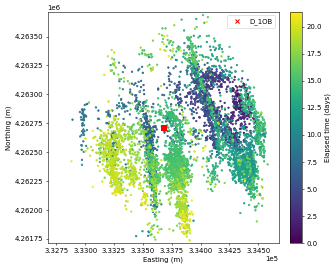

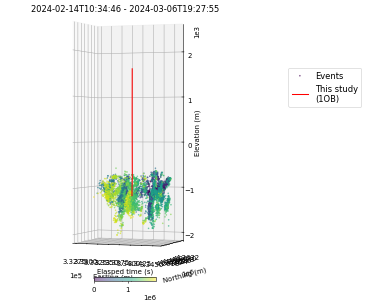

In [5]:
# =============================================================================
plot_events=True
# plot_events=False

# =============================================================================

# Read catalog
infile=os.path.join(opda_dir,'catalog','event_catalog.csv')
cat=pd.read_csv(infile)             
print('Columns in the catalog:')
print(cat.columns)
print('Number of events:',len(cat))

cat['easting']=cat.apply(lambda row: utm.from_latlon(row['lat'], row['lon'])[0],axis=1) 
cat['northing']=cat.apply(lambda row: utm.from_latlon(row['lat'], row['lon'])[1],axis=1)  
cat['evid']=cat.apply(lambda row: UTCDateTime(row['t0']).strftime('%Y%m%d%H%M%S_%f'),axis=1)

cat_t0_list=np.array([UTCDateTime(cat['t0'].values[i]) for i in range(len(cat))])
cat_elapsed_time_list=cat_t0_list-min(cat_t0_list)

cat_dep_list=cat['depth_m'].values
cat_UTMx_list=cat['easting'].values
cat_UTMy_list=cat['northing'].values
cat_lat_list=cat['lat'].values
cat_lon_list=cat['lon'].values
cat_ele_list=cat['elevation_m'].values

if plot_events:

    #% (Plot) MS and wells
    x=cat_UTMx_list
    y=cat_UTMy_list
    s=5
    c=cat_elapsed_time_list/86400
    fig=plt.figure(figsize=[10,6])
    
    ax = plt.gca()
    s1=ax.scatter(x,y,s=s,c=c)
    p1=ax.scatter(x_1OB,y_1OB,color='r',marker='x',label='D_1OB')
    plt.xlabel('Easting (m)')
    plt.ylabel('Northing (m)')
    ax.set_aspect('equal')
    
    ax.ticklabel_format(axis='both', style='sci',scilimits=(0,0))
    cbar=plt.colorbar(s1,ax=ax,pad=0.03)#,shrink=0.3,pad=0.1,aspect=8)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Elapsed time (days)')
    colors=['b','yellow','magenta']
    plt.legend()#bbox_to_anchor=[1.8,0.5])
    ax.set_xlim(np.nanmedian(x_1OB)-1000,np.nanmedian(x_1OB)+1000)
    ax.set_ylim(np.nanmedian(y_1OB)-1000,np.nanmedian(y_1OB)+1000)
    
    plt.show()
    
    
    #%%%% (Plot) Wells & EQs
    
    # =============================================================================
    # xy_bdry=500
    z_bdy=1000
    equal_aspect=True
    # equal_aspect=False
    
    ch_num_1OB=1600 # The first dimension of 1OB data
    s=2
    
    # =============================================================================
    
    fig=plt.figure(figsize=[8,8])
    ax=plt.axes(projection='3d')
    
    x,y,z=cat_UTMx_list, cat_UTMy_list, cat_ele_list
    s1=ax.scatter(xs=x,ys=y,zs=z,s=s,label='Events',c=cat_elapsed_time_list,alpha=0.5)
    
    x1,y1,z1=x_1OB,y_1OB,z_1OB
    plt.plot(x1,y1,z1,label='This study\n(1OB)',color='r',zorder=5)
    plt.legend(bbox_to_anchor=[1.5,0.8],fontsize=12)
    
    ax.set_xlim(np.nanmin(x1)-1000,np.nanmax(x1)+1000)
    ax.set_ylim(np.nanmin(y1)-1000,np.nanmax(y1)+500)
    ax.set_zlim(np.nanmin(z1)-z_bdy,np.nanmax(z1)+z_bdy)
    plt.xlabel('Easting (m)')
    plt.ylabel('Northing (m)')
    ax.set_zlabel('Elevation (m)')
    # world_limits 
    # Equal aspect ratio
    if equal_aspect:
        world_limits = ax.get_w_lims()
        ax.set_box_aspect((world_limits[1]-world_limits[0],
                           world_limits[3]-world_limits[2],
                           world_limits[5]-world_limits[4]))
    
    ax.ticklabel_format(axis='both', style='sci',scilimits=(0,0))
    cbar=plt.colorbar(s1,ax=ax,pad=0.07,shrink=0.2,aspect=16,orientation='horizontal')
    cbar.ax.tick_params(labelsize=10)
    cbar.ax.set_title('Elasped time (s)',fontsize=10)
    # =============================================================================
    ax.view_init(0, 290, 0)
    
    # =============================================================================
    ax.set_title('%s - %s'%(min(cat_t0_list).strftime('%Y-%m-%dT%H:%M:%S'),
                            max(cat_t0_list).strftime('%Y-%m-%dT%H:%M:%S')))
    plt.show()


## Select events based on distance

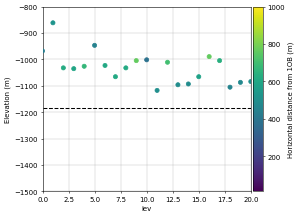

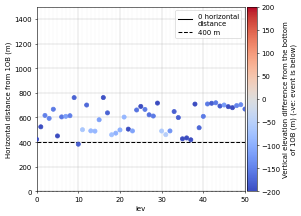

In [6]:
#%% 2. Select events for attenuation
# =============================================================================
# Choose the lowest elevation of the attenuation profile
# Must be larger than the bottom of the well: > np.nanmin(z_1OB)
# One might want to increase this number as cable too close to the source region 
# (at the bottom of the well) might be subject to more near-source effects. Also, 
# cable too deep down might not have too many vertically incident events. Although
# I do filter events with large incident angle out in the end, increasing this number
# here is a simple way to remove those part to reduce computational cost.

min_att_elev=np.nanmin(z_1OB)

# Plot to see how many events are at the well bottom with low incident angle (we want this!)
# I check these plots to determine the distance range of events to filter out in the next block.
plot_result=True
# plot_result= False
# =============================================================================

vec=[(cat_UTMx_list-np.nanmedian(x_1OB)), (cat_UTMy_list-np.nanmedian(y_1OB))]
dis_h=np.linalg.norm(vec,axis=0) # Horizontal distance to D1OB 
dis_v=(min_att_elev-cat_ele_list) # Vertical distance to the bottom of the well D1OB
# Hint: A good event to measure attenuation would have small dis_h (small 
# incident angle) but large dis_v (less near-source effects). 
# I plot the result below and filter out lager dis_h and small dis_v events in the
# next block.

if plot_result:

    #%%% (Examine) (Plot) Find the closest event to D1OB
    fig,ax=plt.subplots()
    x=np.arange(len(dis_h))
    y=cat_ele_list
    s1=plt.scatter(x,y,c=dis_h,zorder=3,vmax=1000)
    ax.axhline(y=np.nanmax(z_1OB),ls='--',color='k',label='Well top')
    ax.axhline(y=np.nanmin(z_1OB),ls='--',color='k',label='Well bottom')
    ax.set_ylabel('Elevation (m)')
    ax.set_xlabel('iev')
    ax.set_ylim(-2000,np.nanmax(z_1OB))
    # =============================================================================
    # Zoom in
    ax.set_xlim(0,20)
    # ax.set_xticks(np.arange(20))
    ax.set_ylim(-1500,-800)
    # =============================================================================
    cbar=plt.colorbar(s1,pad=0.01)
    cbar.ax.set_ylabel('Horizontal distance from 1OB (m)')
    # plt.title('Location: %s'%which_location)
    ax.grid(lw=0.5)
    plt.show()
    
    #%%%%% (Examine) (Plot) Horizontal distance vs iev
    fig,ax=plt.subplots()
    x=np.arange(len(dis_h))
    y=dis_h#-np.nanmin(z_1OB)
    s1=plt.scatter(x,y,c=dis_v,zorder=3,vmax=200,cmap='coolwarm',vmin=-200)
    
    ax.axhline(y=0,ls='-',color='k',label='0 horizontal\ndistance')
    ax.axhline(y=400,ls='--',color='k',label='400 m')
    ax.set_ylabel('Horizontal distance from 1OB (m)')
    ax.set_xlabel('iev')

    cbar=plt.colorbar(s1,pad=0.01)
    cbar.ax.set_ylabel('Vertical elevation difference from the bottom\nof 1OB (m) (-ve: event is below)')
    ax.set_ylim(0,1500)
    
    # =============================================================================
    # Zoom in
    ax.set_xlim(0,50)
    ax.set_xticks(np.arange(50),minor=True)
    
    # =============================================================================
    
    ax.grid(lw=0.5)
    ax.grid(lw=0.1,which='minor')
    plt.legend()
    plt.show()

In [7]:
#%%% Choose events that match the condition (iev_list_for_att)
# =============================================================================
# Select events that have small dis_h (small incident angle) and large dis_v (less near-source effects). 
cond1=(dis_h<400) & (dis_v>400)
# cond1=(dis_h<5000) & (dis_v>0)

# =============================================================================

iev_list_for_att=np.where(cond1)[0]#[:25]
# Initialize
mag_for_att=[]
for iev in iev_list_for_att:
    t0=UTCDateTime(cat_t0_list[iev])
    ind=np.where( (cat_t0_list>=(t0-0.1))&(cat_t0_list<=(t0+0.1)) )[0]
    assert len(ind)==1, 'Found more than 1 corresponsing events.'
    
    cat_target=cat.iloc[ind[0]]
    ev_id=UTCDateTime(cat_target['t0']).strftime('%Y%m%d%H%M%S_%f')
    try:
        mag=cat_target['Mw_DAS'] 
        mag_for_att.append(mag)
    except:
        pass

print('Number of available events for measuring attenuation:',len(iev_list_for_att))
print('iev_list_for_att: This list contains the events that are available for attenuation measurements (based on the criteria you set).')

try:
    print('Min momag:',np.nanmin(mag_for_att))
    print('Max momag',np.nanmax(mag_for_att))
    
except:
    print('If you want to examine the size of the events included, point the magnitude to the magnitude column (Mw_DAS here) in cat.')

Number of available events for measuring attenuation: 18
iev_list_for_att: This list contains the events that are available for attenuation measurements (based on the criteria you set).
Min momag: 0.5273671222242671
Max momag 0.7407693425204975


# Spctral ratio (one event)

## Read spectra

In [38]:
# =============================================================================
iev=iev_list_for_att[11] # Select one event in the iev_list_for_att list


# =============================================================================

In [39]:

# =============================================================================
# For loading the data
which_well='1OB'
# Folder that contain the incident angles for each channels of each event 
inc_angle_dir=os.path.join(opda_dir,'catalog','tt_inc_%s'%P_or_S)
# Folder that contain the travel times for each channels of each event 
tt_dir=os.path.join(opda_dir,'catalog','tt_inc_%s'%P_or_S)
# Folder that contain the arrival picks for each channels of each event 
arr_dir=os.path.join(opda_dir,'catalog','arr_picks_%s'%P_or_S)
# Folder that contain the waveform file for each channels of each event 
wf_dir=os.path.join(opda_dir,'waveforms','phase_%s'%P_or_S)
# =============================================================================

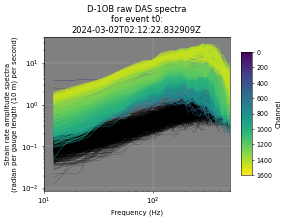

In [40]:
# =============================================================================
show_plot=True

# =============================================================================
cat_target=cat.iloc[iev]                    # Target event catalog
t0=UTCDateTime(cat_target['t0'])                        # Origin time
evid=t0.strftime('%Y%m%d%H%M%S_%f') # evid is formatted using t0
infile=os.path.join(opda_dir,'spectra','spec_D-1OB_%s_arr_%s.npz'%(P_or_S,evid))
r=np.load(infile,allow_pickle=True)                   # Read spectra file
ch_list_partial=r['ch_list_partial'] # Selected channels with good picks
spec_list_partial=r['spec_list_partial']   # P-arrival of raw DAS spectra of selected channels
spec_n_list_partial=r['spec_n_list_partial'] # Noise of raw DAS spectra (0.3 s before the signal window) of selected channels 
f_series=r['f_series'] # Frequency
num_all_ch=1600 # Number of channels in D-1B
fst=1000 # Sampling rate (Hz)
twin=0.1 # Time window for calculating the spectra


#mag=cat_target['DAS_Mw']
cat_ele_list[iev]

# Event coordinates
elev_z_src=cat_target['elevation_m']
utm_x_src=cat_target['easting']
utm_y_src=cat_target['northing']
src_ch=rec_list[np.nanargmin(abs(elev_list-elev_z_src))] # Channel that is the closest to the source elevation

# Load incident angle 
load_filepath_inc_angle=os.path.join(inc_angle_dir,'inc_angles_rad_%s_well%s_id%s.npy'%(P_or_S,which_well,ev_id))
inc_angles_list=np.load(load_filepath_inc_angle)

# Load travel time 
load_filename=os.path.join(tt_dir,'travel_times_%s_well%s_id%s.npy'%(P_or_S,which_well,ev_id))
if not os.path.exists(load_filename):
    raise FileNotFoundError('No travel time file.')
    # print('No travel time for iev:',iev)
    # bad_iev_list.append(iev)
    # continue
tt_list=np.load(load_filename)

# Load arrival picks (for calculating apparent velocity. Can also derive it from theoretical travel time)
arr_infile=os.path.join(arr_dir,'arr_picks_%s_evid%s.npz'%(which_well,ev_id))
if not os.path.exists(arr_infile):
    raise FileNotFoundError('No arrival pick file.')
r=np.load(arr_infile)
arr_picks=r['arr_picks_fil']

# #%%% Calculate smoothed apparent velocity
# =============================================================================
window_size=100
# =============================================================================
x=ch_cumsep_list 
y=arr_picks
y1=ut.moving_average_smoothing(series=y, window_size=window_size)
y2=np.convolve(y1, np.ones(window_size)/window_size, mode='same')
y3=ch_sep_list/(-np.gradient(y2))
app_vp_list=np.convolve(y3, np.ones(window_size)/window_size, mode='same')
    

vec=np.stack([utmX_list,utmY_list,elev_list],axis=-1)-np.array([utm_x_src,utm_y_src,elev_z_src])
dis_m_list=np.linalg.norm(vec,axis=-1) # Straight line hypocentral distance 
chs_nan=np.where(np.isnan(dis_m_list))[0]
chs_valid=np.where(~np.isnan(dis_m_list))[0]

def pad_data_2_correct_channel_number(data_partial,ch_partial,num_all_ch):
    '''
    The spectra files only contain data of selected channels.
    This function pads nans to non-selected channels for the loaded data so that 
    the data sizes are the same for all events: (number of DAS channels in D-1OB 
                                                 (1600), number of time samples)
    
    '''
    # Initialize
    data_full=np.full([num_all_ch, data_partial.shape[1]], np.nan)
    data_full[ch_partial]=data_partial
    return data_full

spec_list=pad_data_2_correct_channel_number(spec_list_partial,ch_list_partial,num_all_ch)
spec_n_list=pad_data_2_correct_channel_number(spec_n_list_partial,ch_list_partial,num_all_ch)  



if show_plot:

    x=f_series
    y1=spec_list
    y2=spec_n_list
    
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(y1)) for i in range(len(y1))]
    
    fig,ax=plt.subplots(figsize=[6,4])
    ax.set_facecolor('gray')
    # Initialize
    spec_all_stack=[]
    for ist in range(len(y1)):
        # ch=mid_ch_list[ist]
        
        indsort=np.argsort(x)
        ax.semilogy(x[indsort],
                    y1[ist][indsort],color=colorst[ist],lw=0.5,zorder=5)
    
        ax.semilogy(x[indsort],
                    y2[ist][indsort],color='k',lw=0.2,zorder=4)        
    
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Strain rate amplitude spectra\n(radian per gauge length (10 m) per second)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(lw=0.5)
    ax.set_xlim(1/twin,fst/2)
    plt.title('D-1OB raw DAS spectra\nfor event t0:\n%s'%(t0))
    norm = mpl.colors.Normalize(vmin=0, vmax=len(colorst))
    cmap=plt.get_cmap("viridis", len(colorst))
    sm = plt.cm.ScalarMappable(norm=norm, cmap=colormap)
    cbar=fig.colorbar(sm,shrink=0.8,aspect=12,ax=ax)
    cbar.ax.invert_yaxis()
    cbar.ax.set_ylabel('Channel')
    cbar.ax.tick_params(labelsize=9)
    
    plt.show()


## SNR threshold and resample

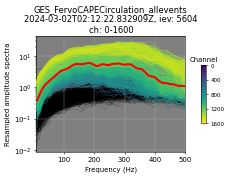

In [41]:
# #%%% (Thr) f range (fmax, fmin)
# =============================================================================
loglog_or_loglinear='loglinear' # Resample in which space? For Q, use loglinear (linear frequency)

snr_limit = 3#*3
show_plot=True
# =============================================================================
# Initialize
fmin_list   = np.zeros(shape=len(spec_list),dtype=float)
fmax_list   = copy(fmin_list )


for i in range(len(spec_list)):
    
    if all(np.isnan(spec_list[i])):
        fmin_list[i], fmax_list[i]=np.nan, np.nan
        continue
    else:
        r = ut.get_f_range_EV(
                spec_list[i], spec_n_list[i],
                f_series, fst, snr_limit)
    
        # Unpack the results
        fmin_list[i], fmax_list[i] = r['fmin'], r['fmax']
        
if loglog_or_loglinear=='loglog':
    #### Log resample (spec_resamp, f_resamp)
    # =============================================================================
    deltaf = 0.05 # in log unit
    nsec = twin
    
    # Maximum available frequency range:
    # lowf_min = 1/nsec # 
    lowf_min=np.nanmin(fmin_list)
    lowf_min
    
    y=spec_list; which_spec='acc'
    # y=specD_list/specD_n_list ; which_spec='dis/dis_n'
    # =============================================================================
    
    highf_max = fst/2 *0.8
    # Initialize
    specs_resamp =[]
    f_resamp = []
    
    for i,sr in enumerate(y):
        f, s  = ut.log_resample( y[i], f_series, np.log10(lowf_min), np.log10(highf_max), deltaf)
        specs_resamp.append(s)
        f_resamp.append(f)
        
    # f_series
    specs_resamp = np.asarray(specs_resamp)
    f_resamp=np.asarray(f_resamp[0])
    f2=f_resamp
    
    # Set part that is outside the f range to nan
    for i, f in enumerate(f_resamp):
        specs_resamp[i] = np.where(f< fmin_list[i], np.nan, specs_resamp[i] )
        specs_resamp[i] = np.where(f> fmax_list[i], np.nan, specs_resamp[i] )
        
    specs_QC=specs_resamp
    
elif loglog_or_loglinear=='loglinear':

    # Set part that is outside the f range to nan
    for i, f in enumerate(f_series):
        spec_list[i] = np.where(f< fmin_list[i], np.nan, spec_list[i] )
        spec_list[i] = np.where(f> fmax_list[i], np.nan, spec_list[i] )        
    specs_QC=spec_list
    f2=f_series

if show_plot:
   # #%%%% (Plot) resampled spec 
    # =============================================================================
    ch_min=0
    ch_max=1600
    
    # =============================================================================
    # np.count_nonzero(specs_resamp.ravel())
    c=specs_QC
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(c)) for i in range(len(c))]
    fig,ax=plt.subplots(figsize=[5,3])
    ax.set_facecolor('gray')
    # Initialize
    stacked_specs_QC=[]
    for ist in range(len(c)):
        # if ist%10==0:
        if ist>ch_min and ist<ch_max:
            ax.semilogy(f2,c[ist],color=colorst[ist],lw=0.5,zorder=5)
            stacked_specs_QC.append(c[ist])
            
            ax.semilogy(f_series[indsort],spec_n_list[ist][indsort],
                        'k',
                        # color=colorst[ist],
                        lw=0.2,zorder=1)
    stacked_specs_QC=np.nanmedian(stacked_specs_QC,axis=0)
    ax.semilogy(f2,stacked_specs_QC,'r',lw=3,zorder=6)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Resampled amplitude spectra')
    # ax.set_ylim(0.5e0,2e1)
    # ax.set_ylim(20,1000)
    ax.set_xlim(10,500)
    if loglog_or_loglinear=='loglog':
        ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(lw=0.5)
    plt.title('GES_FervoCAPECirculation_allevents\n%s, iev: %s'%(t0,iev)+'\nch: %s-%s'%(ch_min,min(ch_max,len(specs_QC))))

    norm = mpl.colors.Normalize(vmin=0, vmax=len(rec_list))
    cb1=fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=colormap),ax=ax,shrink=0.5,aspect=12,pad=0.08)
    
    cb1.ax.invert_yaxis()
    cb1.ax.set_ylim([ch_max,ch_min])
    cb1.ax.set_title('Channel',fontsize=10)
    cb1.ax.tick_params(labelsize=8
                       )
    cb1.ax.set_yticks(np.arange(0,len(rec_list)+1,400))
        
    plt.show()

## Calculate gauge length effects

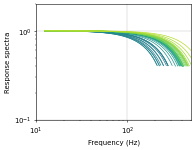

In [42]:

# #%%% Instrument response for selected channels
# =============================================================================
# Response with amplitude lower than the water level is removed to np.nan to prevent amplifying noise.
water_level=4e-1

# Spectra with cutoff frequency (the frequency at which the response spectra drop below the water level) less then lowest_fmax_above_water_level will be completely removed (bad channel).
lowest_fmax_above_water_level=200
plot_response=True
# =============================================================================

# Initialize
resp_list=np.full((len(rec_list),len(f2)),np.nan)
upper_f_list=np.full(len(rec_list),np.nan)
for i in range(len(rec_list)):
    v_app=app_vp_list[i]
    resp=ut.gauge_length_effect_spectra(f=f2,app_vp=v_app,L=gaugeLength)


    if all(np.isnan(resp)):
        continue
    ind=np.where(resp>water_level)[0]
    try:
        upper_f=f2[ind[-1]]
        upper_f_list[i]=upper_f
        if upper_f<lowest_fmax_above_water_level:
            resp_list[i,:]=np.nan
        else:
            resp=np.where(resp>water_level,resp,np.nan)
            resp_list[i,:]=resp
    except IndexError: # index -1 is out of bounds for axis 0 with size 0
        upper_f_list[i]=np.nan
        resp_list[i,:]=np.nan

if plot_response:
    #%%%% (Plot) Response (for MIT thesis)    
    yy=resp_list
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(yy)) for i in range(len(yy))]
    fig,ax=plt.subplots(figsize=[4,3])
    for i,y in enumerate(yy):
        if i>ch_min and i<ch_max and i%20==0:
            ax.semilogy(f2,y,color=colorst[i],lw=1,zorder=5)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Response spectra')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(lw=0.5)
    ax.set_xlim(10,fst/2)
    ax.set_ylim(1e-1,2e0)
        
    plt.show()

## Remove gauge length effects

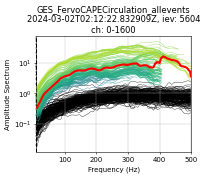

In [43]:
specs_QC_rmresp=specs_QC/resp_list

if show_plot:

    # #%%% Remove instrument response
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(specs_QC)) for i in range(len(specs_QC))]
    
    fig,ax=plt.subplots(figsize=[4,3])
    # Initialize
    spec_QC_rmresp_stack=[]
    
    for ist in range(len(specs_QC)):
        resp=resp_list[ist]

        if ist>ch_min and ist<ch_max and ist%5==0:
            
            y=(specs_QC[ist]/resp)#[indsort]
            ax.semilogy(f2,y,color=colorst[ist],lw=0.5,zorder=5)
            ax.semilogy(f_series,spec_n_list[ist],#[indsort],
                        'k',
                        # color=colorst[ist],
                        lw=0.5,zorder=1)
            spec_QC_rmresp_stack.append(y)
    ax.semilogy(f2,np.nanmedian(spec_QC_rmresp_stack,axis=0),'r',lw=3,zorder=6)
            
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude Spectrum')

    if loglog_or_loglinear=='loglog':
        ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(lw=0.5)
    ax.axvline(x=1/twin,ls='--',color='k')
    ax.axvline(x=fst/2,ls='--',color='k')
    ax.set_xlim(10,fst/2)
    # ax.set_ylim(0.1,2000)
    # ax.set_ylim(1e-3,1e5)
    plt.title('GES_FervoCAPECirculation_allevents\n%s, iev: %s'%(t0,iev)+'\nch: %s-%s'%(ch_min,min(ch_max,len(specs_QC))))
    plt.show()




## Stack nearby channels

/tmp/ipykernel_4187619/1928403334.py:31: RuntimeWarning: All-NaN slice encountered
  spec_stack=np.nanmedian(specs_QC_rmresp[ch0:ch1,:],axis=0)
/tmp/ipykernel_4187619/1928403334.py:32: RuntimeWarning: All-NaN slice encountered
  spec_n_stack=np.nanmedian(specs_n[ch0:ch1,:],axis=0)
/tmp/ipykernel_4187619/1928403334.py:33: RuntimeWarning: All-NaN slice encountered
  mid_elev=np.nanmedian(elev_list[ch0:ch1],axis=0)
/tmp/ipykernel_4187619/1928403334.py:34: RuntimeWarning: All-NaN slice encountered
  mid_dis_m=np.nanmedian(dis_m_list[ch0:ch1],axis=0)
/tmp/ipykernel_4187619/1928403334.py:35: RuntimeWarning: All-NaN slice encountered
  mid_vp=np.nanmedian(vp_profile_well[ch0:ch1],axis=0)
/tmp/ipykernel_4187619/1928403334.py:36: RuntimeWarning: All-NaN slice encountered
  mid_inc=np.nanmedian(inc_angles_list[ch0:ch1],axis=0)
/tmp/ipykernel_4187619/1928403334.py:37: RuntimeWarning: All-NaN slice encountered
  mid_tt=np.nanmedian(tt_list[ch0:ch1],axis=0)


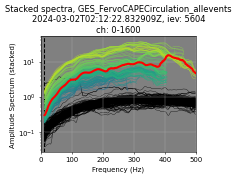

In [44]:
#### Stack spectra
# =============================================================================
       

stack_ch_num=10 # How many channel in one stack
stack_ch_step=5 # How the window step along the fiber

show_plot=True
# =============================================================================

specs_n=spec_n_list # Corresponds to f_series
ind_above_src=np.where(z_1OB>elev_z_src)[0]

# Initialize
spec_stacks=[]
spec_n_stacks=[]
ch0=0
i=0
mid_ch_list=[] 
mid_elev_list=[]
mid_dis_m_list=[]
mid_vp_list=[]
above_src_list=[]
mid_inc_list=[]
mid_tt_list=[] 

while ch0<rec_list[-1]:
    # print(ch1)
    ch0=i*stack_ch_step
    ch1=ch0+stack_ch_num
    spec_stack=np.nanmedian(specs_QC_rmresp[ch0:ch1,:],axis=0) 
    spec_n_stack=np.nanmedian(specs_n[ch0:ch1,:],axis=0) 
    mid_elev=np.nanmedian(elev_list[ch0:ch1],axis=0) 
    mid_dis_m=np.nanmedian(dis_m_list[ch0:ch1],axis=0) 
    mid_vp=np.nanmedian(vp_profile_well[ch0:ch1],axis=0) 
    mid_inc=np.nanmedian(inc_angles_list[ch0:ch1],axis=0) 
    mid_tt=np.nanmedian(tt_list[ch0:ch1],axis=0) 
    
    
    spec_stacks.append(spec_stack)
    spec_n_stacks.append(spec_n_stack)
    mid_ch_list.append((ch0+ch1)//2)
    mid_elev_list.append(mid_elev)
    mid_dis_m_list.append(mid_dis_m)
    mid_vp_list.append(mid_vp)
    mid_inc_list.append(mid_inc)
    mid_tt_list.append(mid_tt)
    if ch1<ind_above_src[-1]:
        above_src_list.append(1)
    else:
        above_src_list.append(0)
    
    i+=1
    
spec_stacks=np.array(spec_stacks)
spec_n_stacks=np.array(spec_n_stacks)
mid_ch_list=np.array(mid_ch_list)
mid_elev_list=np.array(mid_elev_list)
mid_dis_m_list=np.array(mid_dis_m_list)
mid_vp_list=np.array(mid_vp_list)
above_src_list=np.array(above_src_list)
mid_inc_list=np.array(mid_inc_list)
mid_tt_list=np.array(mid_tt_list)

if show_plot:
    # #%%% (Plot) stack spectra: signal vs noise
    
    # =============================================================================
    ch_min=0
    ch_max=1600
    # =============================================================================
    y1=spec_stacks
    y2=spec_n_stacks
    # y1=decons
    # y2=spec_n_stacks
    
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(rec_list)) for i in range(len(rec_list))]
    indsort=np.argsort(f2)
    indsort_n=np.argsort(f_series)
    fig,ax=plt.subplots(figsize=[4,3])
    ax.set_facecolor('gray')
    # Initialize
    spec_all_stack=[]
    for ist in range(len(y1)):
        ch=mid_ch_list[ist]
        if ch>ch_min and ch<ch_max:
            ax.semilogy(f2[indsort],y1[ist][indsort],lw=0.5,zorder=5,color=colorst[ch])
            
            # if which_spec in ['acc']:
            ax.semilogy(f_series[indsort_n],y2[ist][indsort_n],'k',lw=0.5,zorder=1)
            
            spec_all_stack.append(y1[ist][indsort])
    ax.semilogy(f2[indsort],np.nanmedian(spec_all_stack,axis=0),'r',lw=3,zorder=6)
    
            
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude Spectrum (stacked)')
    # ax.set_ylim(1e-1,5e2)
    
    if loglog_or_loglinear=='loglog':
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(10,fst/2)
    else:
        ax.set_xlim(0,fst/2)
    ax.grid(lw=0.5)
    ax.axvline(x=1/twin,ls='--',color='k')
    ax.axvline(x=fst/2,ls='--',color='k')
    plt.title('Stacked spectra, GES_FervoCAPECirculation_allevents\n%s, iev: %s'%(t0,iev)+'\nch: %s-%s'%(ch_min,ch_max))
    plt.show()
    

## Calculate spectral ratio

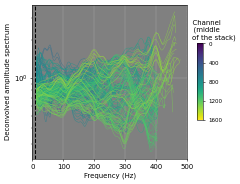

In [45]:
# =============================================================================

decon_stack_sep=16 # Each spectral ratio is the ratio of stacks that are 16 stacks from each other (stack_ch_step(5)*decon_stack_sep(16)*channel separation(2)=160 m apart)
show_plot=True
# =============================================================================


decon_ch_sep=decon_stack_sep*stack_ch_step
decons=spec_stacks/np.concatenate((spec_stacks[decon_stack_sep:,:],np.tile(np.nan, [decon_stack_sep,spec_stacks.shape[1]])),axis=0)

# The representative ch number, coordinate, hypocentral distance for each channel
dec_mid_ch_list=(mid_ch_list.astype(float)+np.pad(mid_ch_list[decon_stack_sep:].astype(float), (0,decon_stack_sep), 'constant', constant_values=np.nan))/2
dec_mid_elev_list=(mid_elev_list.astype(float)+np.pad(mid_elev_list[decon_stack_sep:].astype(float), (0,decon_stack_sep), 'constant', constant_values=np.nan))/2
dec_mid_vp_list=(mid_vp_list.astype(float)+np.pad(mid_vp_list[decon_stack_sep:].astype(float), (0,decon_stack_sep), 'constant', constant_values=np.nan))/2
dec_mid_inc_list=(mid_inc_list.astype(float)+np.pad(mid_inc_list[decon_stack_sep:].astype(float), (0,decon_stack_sep), 'constant', constant_values=np.nan))/2
dec_dis_m_list=(mid_dis_m_list.astype(float)-np.pad(mid_dis_m_list[decon_stack_sep:].astype(float), (0,decon_stack_sep), 'constant', constant_values=np.nan))
dec_dis_ratio_list=(mid_dis_m_list.astype(float)/np.pad(mid_dis_m_list[decon_stack_sep:].astype(float), (0,decon_stack_sep), 'constant', constant_values=np.nan))
dec_dtt_list=(mid_tt_list.astype(float)-np.pad(mid_tt_list[decon_stack_sep:].astype(float), (0,decon_stack_sep), 'constant', constant_values=np.nan))
if show_plot:
    #% (Plot) decons
    
    # =============================================================================
    
    ch_min=0
    ch_max=1600
    # =============================================================================
    
    y1=decons
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(rec_list)) for i in range(len(rec_list))]
    indsort=np.argsort(f2)
    fig,ax=plt.subplots(figsize=[5,4])
    ax.set_facecolor('gray')
    # Initialize
    spec_all_stack=[]
    for ist in range(len(y1)):
        ch=mid_ch_list[ist]
        if ch>ch_min and ch<ch_max and ist%1==0:
            ax.semilogy(f2[indsort],y1[ist][indsort],color=colorst[ch],lw=0.5,zorder=5)
            spec_all_stack.append(y1[ist][indsort])
    
            
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Deconvolved amplitude spectrum')
    # ax.set_ylim(1e-1,5e2)
    if loglog_or_loglinear=='loglog':
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(10,fst/2)
    else:
        ax.set_xlim(0,fst/2)
    
    ax.grid(lw=0.5)
    ax.axvline(x=1/twin,ls='--',color='k')
    ax.axvline(x=fst/2,ls='--',color='k')
    # plt.title('%s, iev: %s, M=%.02f'%(data_subdir,iev,mag)+'\ndecon_ch_sep: %d, ch: %s-%s'%(decon_ch_sep,ch_min,ch_max))
    norm = mpl.colors.Normalize(vmin=0, vmax=len(rec_list))
    cb1=fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=colormap),ax=ax,shrink=0.5,aspect=12)
    
    cb1.ax.invert_yaxis()
    cb1.ax.set_ylim([ch_max,ch_min])
    cb1.ax.set_title('      Channel\n      (middle\n            of the stack)',fontsize=10)
    cb1.ax.tick_params(labelsize=8
                       )
    cb1.ax.set_yticks(np.arange(0,len(rec_list)+1,400))
    plt.show()

## Save spectral ratios

In [46]:
# =============================================================================
overwrite=True
# =============================================================================

outdir=os.path.join(opda_dir, 'save','decons_for_att')
os.makedirs(outdir,exist_ok=True)
outfile=os.path.join(outdir,'decons_neighboring_%s_%s_evid%s_decon_stack_sep%s_stack_ch_num%s_stack_ch_step%s.npz'%(P_or_S,which_well,
    ev_id,decon_stack_sep,stack_ch_num,stack_ch_step))

if os.path.exists(outfile) and overwrite ==False:
    raise FileExistsError('File exist. Set overwite=True to overwrite.')
    # print("Pass exsiting event: %s"%iev)
    # return 0
    
else:
   
    np.savez(outfile,
             decon_ch_sep=decon_ch_sep,
             decons=decons,
             dec_mid_ch_list=dec_mid_ch_list,
             dec_mid_elev_list=dec_mid_elev_list,
             dec_mid_vp_list=dec_mid_vp_list,
             dec_mid_inc_list=dec_mid_inc_list,
             dec_dis_m_list=dec_dis_m_list,
             dec_dis_ratio_list=dec_dis_ratio_list,
             dec_dtt_list=dec_dtt_list,
             above_src_list=above_src_list,
             resp_list=resp_list,
             f2=f2,
             upper_f_list=upper_f_list
             )
    
    print('Saved as', outfile)

Saved as /mnt/data0/hilarych/FORGE_2024/save/open_data_Fervo/save/decons_for_att/decons_neighboring_P_1OB_evid20240302021222_832909_decon_stack_sep16_stack_ch_num10_stack_ch_step5.npz


# Fit Q (one event)

In [47]:
# =============================================================================
iev=iev_list_for_att[11] # Select one event in the iev_list_for_att list


# =============================================================================

In [48]:
# =============================================================================
# Fitting parameters

fit_frange=[20,200] # Which f range to determine Q
Q_range=[1,5000] # Possible Q range
inc_deg_range=[0,30] # Only use channels and events with incident angle <30 (for P wave)

# These are for reading the spectral ratio data:
decon_stack_sep=16
stack_ch_num=10 # How many channel in one stack
stack_ch_step=5 # How the window step along the fiber

# =============================================================================

## Load spectral ratios

In [49]:
t0=UTCDateTime(cat_t0_list[iev])
cat_target=cat.iloc[iev]
ev_id=cat_target['evid']
elev_z_src=cat_target['elevation_m']
indir=os.path.join(opda_dir, 'save','decons_for_att')
infile=os.path.join(indir,'decons_neighboring_%s_%s_evid%s_decon_stack_sep%s_stack_ch_num%s_stack_ch_step%s.npz'%(P_or_S,
which_well,ev_id,decon_stack_sep,stack_ch_num,stack_ch_step))
if os.path.exists(infile)==False:
    raise FileNotFoundError('No spectral ratio data.')

else:
    r=np.load(infile)
    
    decon_ch_sep=r['decon_ch_sep']
    decons=np.array(r['decons'])
    dec_mid_ch_list=r['dec_mid_ch_list']
    dec_mid_elev_list=r['dec_mid_elev_list']
    dec_mid_vp_list=r['dec_mid_vp_list']
    dec_mid_inc_list=r['dec_mid_inc_list']
    dec_dis_m_list=r['dec_dis_m_list']
    dec_dis_ratio_list=r['dec_dis_ratio_list']
    above_src_list=r['above_src_list']
    dec_dtt_list=r['dec_dtt_list']
    resp_list=r['resp_list']
    upper_f_list=r['upper_f_list']
    f2=r['f2']
    ind_below_src=np.where(~(above_src_list.astype(bool)))[0]
    decons[ind_below_src,:]=np.nan
    
    
    ind_bad_inc=np.where((dec_mid_inc_list<np.deg2rad(inc_deg_range[0]))|( dec_mid_inc_list>np.deg2rad(inc_deg_range[1])))[0]
    decons[ind_bad_inc,:]=np.nan


    geo_spreading_list=(dec_dis_ratio_list)**-1
    yy=decons    
    r_list=[]
    stderr_Q_list=np.full(len(yy), np.nan)
    Q_list=np.full(len(yy), np.nan)
    lowf_amp_list=np.full(len(yy), np.nan)
    chisqr_list=np.full(len(yy), np.nan)
    redchi_list=np.full(len(yy), np.nan)

## Fit stack spectral ratios

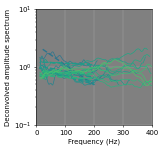

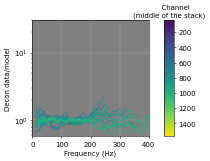

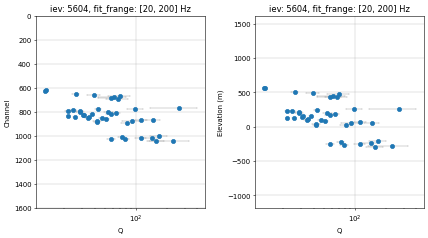

In [50]:
# =============================================================================
show_plot=True

# =============================================================================
for i, y in enumerate(yy):
    
    # if ~np.isnan(tt_list[i]):
    if True:
    
        upper_f=upper_f_list[i]
        result= ut.fit_att_term(
            x=f2,
            y=y,
            # dx=dec_dis_m_list[i], # (used)
            # v=dec_mid_vp_list[i], # (used)
            # v=interp_vp_func(dec_mid_vp_list[i]), # (Not used)
            
            tt=dec_dtt_list[i],
            init_Q=300,
            init_Omega0=geo_spreading_list[i],
            varying_Omega0=True,
            # varying_Omega0=False,
            
            fit_frange=[fit_frange[0], np.nanmin([fit_frange[1],upper_f])],
            Q_range=Q_range,
            method='least_sqaures',
            nan_policy='propagate'
            )
        
        r_list.append(result)
        if type(result)!=float:
            Q_list[i]=result.params['Q'].value
            stderr_Q_list[i]=result.params['Q'].stderr
            lowf_amp_list[i]=result.params['Omega0'].value
            chisqr_list[i]=result.chisqr
            redchi_list[i]=result.redchi


# Filter bad results
ind=np.where( ((Q_list+1)>Q_range[1]) | ((Q_list-1)<Q_range[0]) )[0]
Q_list[ind]=np.nan
stderr_Q_list[ind]=np.nan
lowf_amp_list[ind]=np.nan

s_model = lmfit.Model(ut.att_term)
# Initialize
model_decons=np.full(decons.shape,np.nan)
for i, decon in enumerate(decons):
    # Omega0=geo_spreading_list[i]
    if ~np.isnan(dec_dtt_list[i]):
        
        Omega0=lowf_amp_list[i]
        
        model_decon=Omega0*s_model.eval(
                    # dx=dec_dis_m_list[i], (used)
                    # v=dec_mid_vp_list[i], (used)
                    # v=interp_vp_func(dec_mid_vp_list[i]), # (not used) 
                    
                    tt=dec_dtt_list[i],
                    Q= Q_list[i], f=f2)
        model_decons[i]=model_decon
# model_decons=np.array(model_decons)

res_decons=decons/model_decons
if show_plot:

    #### (Plot) Model and decon
    # =============================================================================
    x=np.copy(f2)
    yy=np.copy(decons)
    
    yy1=np.copy(model_decons)
    ymin,ymax=0.1,10
    
    sep=5
    yy1.shape
    max_unc_Q=50
    
    
    # =============================================================================
    
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(rec_list)) for i in range(len(rec_list))]
    ind=np.where(stderr_Q_list/Q_list*100>max_unc_Q)[0]
    yy[ind]=np.nan
    yy1[ind]=np.nan


    
    ind=np.where((x<fit_frange[0])|(x>fit_frange[1]))[0]
    yy1[:,ind]=np.nan
    
    fig, ax = plt.subplots(figsize=[3,3])
    
    yy.shape
    ax.set_facecolor('gray')
    plt.grid(True)
    # Initialize
    i_plotted=[]
    
    
    
    for i, y in enumerate(yy):
        # if stderr_Q_list[i]!=None and i in np.arange(0,80,sep):
        # if stderr_Q_list[i]!=None and i in np.arange(80,150,sep):
        # if stderr_Q_list[i]!=None and i in np.arange(150,300,sep):
        if stderr_Q_list[i]!=None and i in np.arange(0,300,sep):
            ch=int(dec_mid_ch_list[i])
            isNan=np.isnan(y)
            x_selected=x[~isNan]
            y_selected=y[~isNan]  
            y1_selected=yy1[i][~isNan]  
            i_plotted.append(i)
        
            if loglog_or_loglinear=='loglog':
                plt.loglog(x_selected, y_selected, linewidth=1,marker=None,label=None,
                           color=colorst[ch])
                plt.loglog(x_selected,y1_selected,color=colorst[ch],linestyle='dashed',
                            linewidth=2,label='$Q={:.01f}\pm{:.01f}$ ({:.01f}%)'.format(
                                Q_list[i],stderr_Q_list[i],stderr_Q_list[i]/Q_list[i]))
            if loglog_or_loglinear=='loglinear':
                plt.semilogy(x_selected, y_selected, linewidth=1,marker=None,label=None,
                           color=colorst[ch])
                plt.semilogy(x_selected,y1_selected,color=colorst[ch],linestyle='dashed',
                            linewidth=2,label='$Q={:.01f}\pm{:.01f}$ ({:.01f}%)'.format(
                                Q_list[i],stderr_Q_list[i],stderr_Q_list[i]/Q_list[i]))
    ax.set_xlabel("Frequency (Hz)")
    # ax.set_ylabel('Deconvolved amplitude spectrum')
    ax.set_ylabel('Deconvolved amplitude spectrum')
    plt.xlim(0,400)
    plt.ylim([ymin,ymax])
    plt.grid(which='both',linewidth=0.5,axis='x')
    plt.grid(which='major',linewidth=0.5,axis='y')
    # plt.legend(loc='lower left')
    # plt.legend(loc='best',fontsize=12)
    plt.show()


    # #### (Plot) Residual
    # =============================================================================
    x=np.asarray(f2)
    yy=np.asarray(res_decons)
    
    ymin,ymax=1,10
    
    
    # =============================================================================
    
    colormap = plt.cm.viridis
    # colorst = [colormap(i/len(yy)) for i in range(len(yy))]
    colorst = [colormap(i/len(rec_list)) for i in range(len(rec_list))]
    
    fig, ax = plt.subplots(figsize=[4,3])
    
    ax.set_facecolor('gray')
    plt.grid(True)
    # Initialize
    i_plotted=[]
    for i, y in enumerate(yy):
        # if stderr_Q_list[i]!=None and i in np.arange(0,80,1):
        # if stderr_Q_list[i]!=None and i in np.arange(80,300,1):
        # if stderr_Q_list[i]!=None and i in np.arange(150,300,1):
        if stderr_Q_list[i]!=None and i in np.arange(0,300,2):
            ch=int(dec_mid_ch_list[i])
            isNan=np.isnan(y)
            x_selected=x[~isNan]
            y_selected=y[~isNan]  
            y1_selected=yy1[i][~isNan]  
            i_plotted.append(i)
            if loglog_or_loglinear=='loglog':
                plt.loglog(x_selected, y_selected, linewidth=1,marker=None,label=None,
                           color=colorst[ch])
            if loglog_or_loglinear=='loglinear':
                plt.semilogy(x_selected, y_selected, linewidth=1,marker=None,label=None,
                           color=colorst[ch])
    
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel('Decon data/model')

    plt.xlim(0,400)
    plt.ylim(None,30)
    # plt.ylim(0.07,1.5)
    plt.grid(which='both',linewidth=0.5,axis='x')
    plt.grid(which='major',linewidth=0.5,axis='y')
    # plt.legend(loc='lower left')
    # plt.legend(loc='best',fontsize=12)
    
    norm = mpl.colors.Normalize(vmin=0, vmax=len(rec_list))
    cb1=fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=colormap),ax=ax,shrink=1,aspect=12,pad=0.1)
    cb1.ax.set_ylim([min(dec_mid_ch_list),max(dec_mid_ch_list)])
    cb1.ax.invert_yaxis()
    cb1.ax.set_title('      Channel\n(middle of the stack)',fontsize=10)
    cb1.ax.tick_params(labelsize=10
                       )
    
    plt.show()
    
    #### (Plot) Q profile (vs channel and elevations)
    # =============================================================================
    max_unc_Q=50 # Maxmimun allowed uncertainty (std/result)
    
    # =============================================================================
    y1=dec_mid_ch_list
    x=np.where(stderr_Q_list!=None,Q_list,np.nan)
    xerr=np.where(stderr_Q_list!=None,stderr_Q_list,np.nan)
    
    ind=np.where(xerr/x*100>max_unc_Q)[0]
    x[ind]=np.nan
    xerr[ind]=np.nan
    if all(np.isnan(x)):
        print('No good Q results for this event.')
    else:
    
        fig=plt.figure(figsize=[10,5])
        gs=GridSpec(1, 2,wspace=0.3)
        
        # Initialize
        axs=[]
        axs.append(fig.add_subplot(gs[0]))
        ax=axs[-1]
        
        ax.scatter(x,y1,zorder=3)
        ax.errorbar(x, y1, xerr=xerr,capsize=1,lw=0,ms=0,capthick=0.3,color='grey',elinewidth=0.5)
        
        ax.set_ylabel('Channel')
        ax.set_xlabel('Q')
        ax.set_xscale('log')
        ax.invert_yaxis()
        ax.set_ylim([1600,0])
        ax.grid(True,lw=0.5)
        ax.set_title('iev: %s, fit_frange: %s Hz'%(iev,fit_frange))
        
        axs.append(fig.add_subplot(gs[1]))
        ax=axs[-1]
        y2=dec_mid_elev_list
        ax.scatter(x,y2,zorder=3)
        ax.errorbar(x, y2, xerr=xerr,capsize=1,lw=0,ms=0,capthick=0.3,color='grey',elinewidth=0.5)
        ax.axhline(y=elev_z_src,color='k',ls='--')
        ax.set_ylabel('Elevation (m)')
        ax.set_xlabel('Q')
        
        ax.set_title('iev: %s, fit_frange: %s Hz'%(iev,fit_frange))
        ax.grid(True,lw=0.5)
        ax.set_xscale('log')
        ax.set_ylim([np.nanmin(z_1OB),np.nanmax(z_1OB)])
        plt.show()
        

## Save Q profile

In [51]:
#### (Save) Q profile for an event
save_dir=os.path.join(opda_dir, 'save','Q_profiles')
os.makedirs(save_dir,exist_ok=True)
outfile=os.path.join(save_dir,'Q_profile_%s_%s_id%s_fit%d-%dHz.npz'%(P_or_S,which_well,ev_id,fit_frange[0],fit_frange[1]))
np.savez(outfile,
         dec_mid_ch_list=dec_mid_ch_list,
         dec_mid_elev_list=dec_mid_elev_list,
         stderr_Q_list=stderr_Q_list,
         Q_list=Q_list,
         chisqr_list=chisqr_list,
         redchi_list=redchi_list,
         stack_ch_num=stack_ch_num,
         stack_ch_step=stack_ch_step,
         decon_stack_sep=decon_stack_sep
     )
print('Saved as',outfile)


Saved as /mnt/data0/hilarych/FORGE_2024/save/open_data_Fervo/save/Q_profiles/Q_profile_P_1OB_id20240302021222_832909_fit20-200Hz.npz


# Analyze Q results from events

## Load events Q and filter bad values

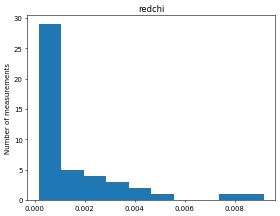

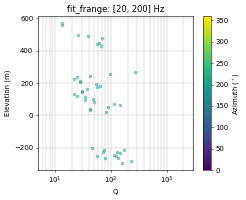

In [52]:
#%% (Load) Q from events
# =============================================================================

# Set these thresholds to filter out results with too large uncertainty (std/result)
max_unc_Q=50

# These are for loading the results
fit_frange=[20,200]
stack_ch_num=10 # How many channel in one stack
stack_ch_step=5 # How the window step along the fiber
decon_stack_sep=16


# =============================================================================

load_dir=os.path.join(opda_dir, 'save','Q_profiles')
infile_list=glob(os.path.join(load_dir,'Q_profile_%s_%s_id*_fit%d-%dHz.npz'%(P_or_S,which_well,fit_frange[0],fit_frange[1])))

# An entended list
dec_mid_ch_lists=[]
dec_mid_elev_lists=[]
unc_Q_lists=[]
stderr_Q_lists=[]
Q_lists=[]
chisqr_lists=[]
redchi_lists=[]

# Appended lists
dec_mid_ch_list_evs=[]
dec_mid_elev_list_evs=[]
unc_Q_list_evs=[]
stderr_Q_list_evs=[]
Q_list_evs=[]
chisqr_list_evs=[]
redchi_list_evs=[]
t0_list_evs=[]
az_list_evs=[]

      

for infile in infile_list:
    ev_id=os.path.basename(infile).split('id')[-1].split('_fit')[0]
    cat_target=cat[cat['evid']==ev_id]
    t0=UTCDateTime(cat_target.t0.values[0])

    vec=[(cat_target['easting']-np.nanmedian(x_1OB)), (cat_target['northing']-np.nanmedian(y_1OB))]
    az=ut.calculate_azimuth(vec)
    r=np.load(infile)
    dec_mid_ch_list1=r['dec_mid_ch_list']
    dec_mid_elev_list1=r['dec_mid_elev_list']
    stderr_Q_list=r['stderr_Q_list']
    
    
    chisqr_list=r['chisqr_list']
    redchi_list=r['redchi_list']
    Q_list=r['Q_list']
    unc_Q_list=stderr_Q_list/Q_list*100
    
    # Filter
    ind=np.where(unc_Q_list<max_unc_Q)[0]
    Q_list=Q_list[ind]
    stderr_Q_list=stderr_Q_list[ind]
    unc_Q_list=unc_Q_list[ind]   
    chisqr_list=chisqr_list[ind]
    redchi_list=redchi_list[ind]
    dec_mid_ch_list1=dec_mid_ch_list1[ind]
    dec_mid_elev_list1=dec_mid_elev_list1[ind]

    
    # Extended list
    Q_lists.extend(Q_list)
    stderr_Q_lists.extend(stderr_Q_list)
    unc_Q_lists.extend(unc_Q_list)
    
    
    chisqr_lists.extend(chisqr_list)
    redchi_lists.extend(redchi_list)
    dec_mid_ch_lists.extend(dec_mid_ch_list1)
    dec_mid_elev_lists.extend(dec_mid_elev_list1)

    # Appended list
    Q_list_evs.append(Q_list)
    stderr_Q_list_evs.append(stderr_Q_list)
    unc_Q_list_evs.append(unc_Q_list)
    chisqr_list_evs.append(chisqr_list)
    redchi_list_evs.append(redchi_list)
    dec_mid_ch_list_evs.append(dec_mid_ch_list1)
    dec_mid_elev_list_evs.append(dec_mid_elev_list1)    
    t0_list_evs.append(t0)
    az_list_evs.append(az)

t0_list_evs=np.array(t0_list_evs)
elasped_time_list_evs=t0_list_evs-min(t0_list_evs)

# Convert to np array
unc_Q_lists=np.array(unc_Q_lists)
stderr_Q_lists=np.array(stderr_Q_lists)
Q_lists=np.array(Q_lists)
chisqr_lists=np.array(chisqr_lists)
redchi_lists=np.array(redchi_lists)
dec_mid_ch_lists=np.array(dec_mid_ch_lists)
dec_mid_elev_lists=np.array(dec_mid_elev_lists)
az_list_evs=np.array(az_list_evs)

# Sort the extended lists by channel
indsort=np.argsort(dec_mid_ch_lists)
dec_mid_ch_lists=dec_mid_ch_lists[indsort]
dec_mid_elev_lists=dec_mid_elev_lists[indsort]
Q_lists=Q_lists[indsort]
stderr_Q_lists=stderr_Q_lists[indsort]
unc_Q_lists=unc_Q_lists[indsort] 
redchi_lists=redchi_lists[indsort] 
chisqr_lists=chisqr_lists[indsort]

unc_Q_lists=stderr_Q_lists/Q_lists*100
#%%% Filter poor values

fig,ax=plt.subplots()
ax.hist(redchi_lists); ax.set_title('redchi')
# ax.hist(unc_Q_lists); ax.set_title('unc_Q')
ax.set_ylabel('Number of measurements')
plt.show()

# =============================================================================
# Set these thresholds to filter out results with too large uncertainty (std/result)
max_redchi=0.05


# =============================================================================

# Filter extended lists
cond=~((redchi_lists<max_redchi)&(unc_Q_lists<max_unc_Q))
ind=np.where(cond)[0]
Q_lists[ind]=np.nan
stderr_Q_lists[ind]=np.nan

# Filter appended lists
for i in range(len(Q_list_evs)):
    cond=~((redchi_list_evs[i]<max_redchi)&(unc_Q_list_evs[i]<max_unc_Q))
    ind=np.where(cond)[0]
    Q_list_evs[i][ind]=np.nan
    stderr_Q_list_evs[i][ind]=np.nan



#%%% (Plot) Q at channels all events
# =============================================================================
which_to_plot='elev'

# which_to_plot='ch'
# which_to_plot='depth'

# color_by='time'
color_by='az (deg)'

# =============================================================================
cmap=plt.cm.viridis

fig,ax=plt.subplots(figsize=[5,4])
xx=Q_list_evs

if which_to_plot=='ch':
    yy=dec_mid_ch_list_evs
    ylabel='Channel'
elif which_to_plot=='elev':
    yy=dec_mid_elev_list_evs
    ylabel='Elevation (m)'

elif which_to_plot=='depth':
    yy=dec_mid_elev_list_evs
    yy=[np.abs(dec_mid_elev_list-np.nanmax(elev_list)) for dec_mid_elev_list in dec_mid_elev_list_evs]
    ylabel='Depth (m)'


if color_by=='time':
    ccc=elasped_time_list_evs/86400
    clabel='Elapsed time (day)'
    norm = mpl.colors.Normalize(vmin=np.nanpercentile(ccc,5), vmax=np.nanpercentile(ccc,95))
elif color_by=='az (deg)':
    ccc=np.rad2deg(az_list_evs)
    clabel=r'Azimuth ($^\circ$)'
    norm = mpl.colors.Normalize(vmin=0, vmax=360)

for i,x in enumerate(xx):
    ind1=np.where(np.array(dec_mid_elev_list_evs[i])<min_att_elev+100)[0]
    y=np.copy(yy[i])
    c=np.copy(ccc[i])
    # try:
    y[ind1]=np.nan
    ax.scatter(x,y,zorder=3,color=cmap(norm(c)),lw=0.5,alpha=0.5,s=20)
    # except IndexError:
    #     pass


ax.set_ylabel(ylabel)
ax.set_xlabel('Q')
ax.set_xscale('log')
np.nanmin(y2)
# ax.set_ylim([np.nanmin(yy),np.nanmax(yy)])
if which_to_plot in ['ch','depth']:
    ax.invert_yaxis()

ax.grid(which='both',lw=0.5)
ax.set_title('fit_frange: %s Hz'%(fit_frange))
ax.set_xlim(5,3000)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  # only needed for matplotlib < 3.1
cbar=plt.colorbar(sm,ax=ax)
cbar.set_label(clabel)

# ax.set_axis_off()
plt.show()


## Calculate average Q at each DAS channel

In [53]:
#%%% Calculate Q at channels

# =============================================================================
stack_ch_num=20 # How many channel in one stack
min_stack_num=20

# =============================================================================
# Initialize
med_Q_chs=np.full(len(rec_list),np.nan)
stderr_Q_chs=np.full(len(rec_list),np.nan)
mad_Q_chs=np.full(len(rec_list),np.nan)
for i in range(len(rec_list)):
    i0=max(0,i-stack_ch_num)
    i1=min(i+stack_ch_num,len(rec_list)+1)
    ind=np.where( (dec_mid_ch_lists>=i0)&(dec_mid_ch_lists<i1) )[0]
    # print(ind)
    if len(ind)<min_stack_num:
        continue
    med_Q_chs[i]=np.nanmedian(Q_lists[ind].ravel())
    stderr_Q_chs[i]=np.nanstd(Q_lists[ind].ravel())
    mad_Q_chs[i]=scipy.stats.median_abs_deviation(Q_lists[ind])



## Save average Q profile

I comment it out because it needs many events (repeating 2 and 3 for many times for more than 100 events in iev_for_att_list) to get a good Q profile. I have saved the results I got using 100+ events.

In [ ]:
#%%%%%% (Save) Q profile
# # =============================================================================
# overwrite=False

# # =============================================================================
# save_dir=os.path.join(opda_dir,'models')
# outfile=os.path.join(save_dir,'Q_profile_%s_%s_events_fit%d-%dHz.npz'%(P_or_S,which_well,fit_frange[0],fit_frange[1]))
# if os.path.exists(outfile) and overwrite ==False:
#     raise FileExistsError('File exist. Set overwite=True to overwrite.')
# else:
#     np.savez(outfile,
#               med_Q_chs=med_Q_chs,
#               mad_Q_chs=mad_Q_chs,
#               rec_list=rec_list,
#               stack_ch_num=stack_ch_num,
#               stack_ch_step=stack_ch_step,
#               decon_stack_sep=decon_stack_sep
#           )
#     print('Saved as',outfile)


## Load and plot average Q

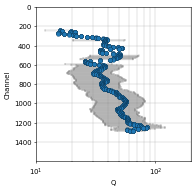

In [56]:
# =============================================================================

show_plot=True

# =============================================================================
load_dir=os.path.join(opda_dir,'models')
infile=os.path.join(load_dir,'Q_profile_%s_%s_events_fit%d-%dHz.npz'%(P_or_S,which_well,fit_frange[0],fit_frange[1]))
r=np.load(infile)
med_Q_chs=r['med_Q_chs']
mad_Q_chs=r['mad_Q_chs']


if show_plot:
    #%%%%%%% (Plot) Q at channels
    # =============================================================================
    # which_to_plot='elev'
    # which_to_plot='depth'
    which_to_plot='ch'
    
    # =============================================================================
    
    
    fig,ax=plt.subplots(figsize=[4,4])
    x1=Q_lists
    
    if which_to_plot=='ch':
        y2=rec_list
        ylabel='Channel'
        ylim=[rec_list[0],rec_list[-1]]
    elif which_to_plot=='elev':
        y2=elev_list
        ylabel='Elevation (m)'
        ylim=[np.nanmin(z_1OB),np.nanmax(z_1OB)]
    elif which_to_plot=='depth':
        y2=np.abs(elev_list-np.nanmax(elev_list))
        ylabel='Depth (m)'
        ylim=[0,np.nanmax(y2)]
    elev_list
    x2=med_Q_chs
    xerr=mad_Q_chs
    # ax.scatter(x1,y1,zorder=3)
    ax.scatter(x2,y2,zorder=3,edgecolor='k',lw=0.2)
    ax.errorbar(x2, y2, xerr=xerr,capsize=1,lw=0,ms=0,capthick=0.3,color='grey',elinewidth=0.2,alpha=0.5)
    
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Q')
    ax.set_xscale('log')
    ax.set_ylim(ylim)
    if which_to_plot in ['ch','depth']:
        ax.invert_yaxis()
    
    ax.grid(which='both',lw=0.5)
    # ax.set_title('fit_frange: %s Hz'%(fit_frange))
    ax.set_xlim(10,200)
    plt.show()